# 🌡️ Actuarial Climate Risk Engine

## Assessing the Impact of Temperature Changes on Insurance Portfolios

This notebook demonstrates the complete workflow of the Actuarial Climate Risk Engine, which:

1. **Module 1 (MortalityAdjuster)**: Applies temperature-based Exposure Response Functions (ERFs) to "shock" baseline mortality tables
2. **Module 2 (PortfolioValuation)**: Calculates insurance reserves using actuarial commutation functions
3. **ClimateRiskEngine**: Combines both modules to quantify the financial impact of climate change on insurance portfolios

---

In [2]:
# Import the actuarial engine modules
from actuarial_engine import (
    MortalityAdjuster,
    PortfolioValuation,
    ClimateRiskEngine,
    generate_sample_mortality_table,
    generate_sample_portfolio,
    create_erf_function
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Actuarial Climate Risk Engine loaded successfully!")

✅ Actuarial Climate Risk Engine loaded successfully!


## 1. Generate Baseline Data

### 1.1 Baseline Mortality Table

We use the **Gompertz-Makeham** law of mortality to generate a realistic baseline:

$$\mu(x) = A + B \cdot c^x$$

Where:
- $\mu(x)$ = force of mortality at age $x$
- $A$ = age-independent mortality (accidents, etc.)
- $B$ = initial mortality level
- $c$ = rate of mortality increase with age

In [3]:
# Generate baseline mortality table
mortality_table = generate_sample_mortality_table(max_age=100)

print(f"Mortality table: {len(mortality_table)} ages (0-100)")
print("\nSample data:")
mortality_table.head(10)

Mortality table: 101 ages (0-100)

Sample data:


,age,qx
0,0,0.0060
1,1,0.0001
2,2,0.0001
3,3,0.0001
4,4,0.0001
5,5,0.0001
6,6,0.0002
7,7,0.0002
8,8,0.0002
9,9,0.0002


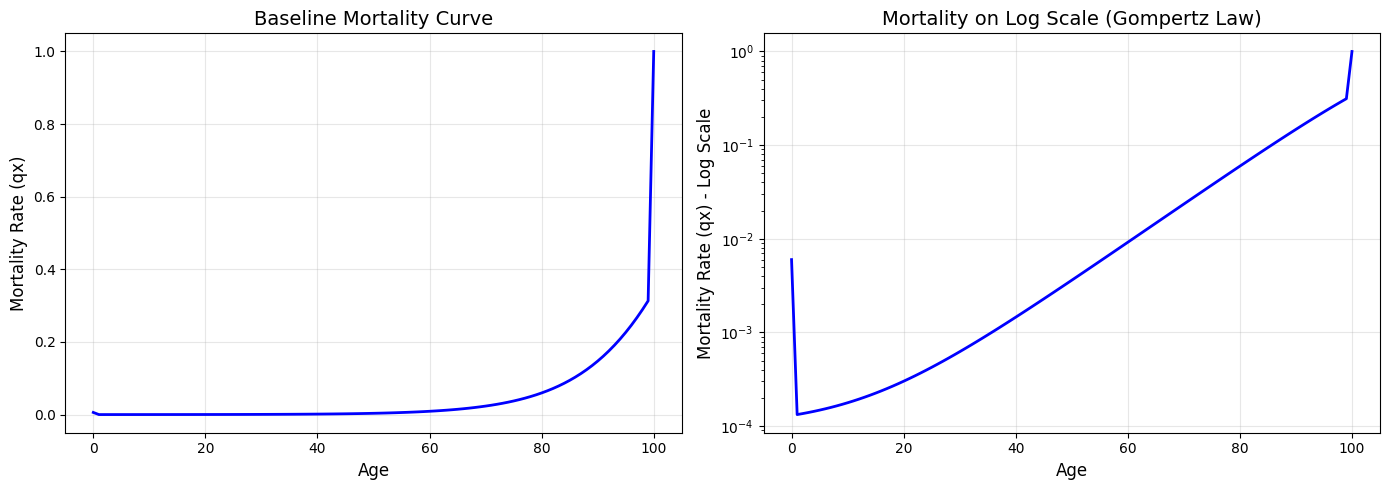

In [3]:
# Visualize baseline mortality curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(mortality_table['age'], mortality_table['qx'], 'b-', linewidth=2)
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Mortality Rate (qx)', fontsize=12)
axes[0].set_title('Baseline Mortality Curve', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Log scale (shows Gompertz linearity)
axes[1].semilogy(mortality_table['age'], mortality_table['qx'], 'b-', linewidth=2)
axes[1].set_xlabel('Age', fontsize=12)
axes[1].set_ylabel('Mortality Rate (qx) - Log Scale', fontsize=12)
axes[1].set_title('Mortality on Log Scale (Gompertz Law)', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 Sample Insurance Portfolio

Generate a mixed portfolio of:
- **Annuities** (60%): Company pays while policyholder lives
- **Life Insurance** (40%): Company pays when policyholder dies

In [4]:
# Generate sample portfolio
portfolio = generate_sample_portfolio(n_policies=100, seed=42)

print(f"Portfolio: {len(portfolio)} policies")
print(f"\nProduct mix:")
print(portfolio['product_type'].value_counts())

print(f"\nTotal volume by product:")
print(portfolio.groupby('product_type')['volume'].sum().apply(lambda x: f"${x:,.0f}"))

print("\nSample policies:")
portfolio.head(10)

Portfolio: 100 policies

Product mix:
product_type
Annuity           59
Life Insurance    41
Name: count, dtype: int64

Total volume by product:
product_type
Annuity           $17,564,901
Life Insurance    $21,454,319
Name: volume, dtype: object

Sample policies:


,age,product_type,volume
0,46,Annuity,338914.2408
1,75,Life Insurance,175725.9685
2,61,Annuity,122732.9213
3,55,Annuity,454349.3848
4,35,Life Insurance,645786.1537
5,35,Annuity,54138.6732
6,29,Annuity,95662.1943
7,69,Life Insurance,697151.5922
8,55,Annuity,52277.7127
9,60,Annuity,122363.6231


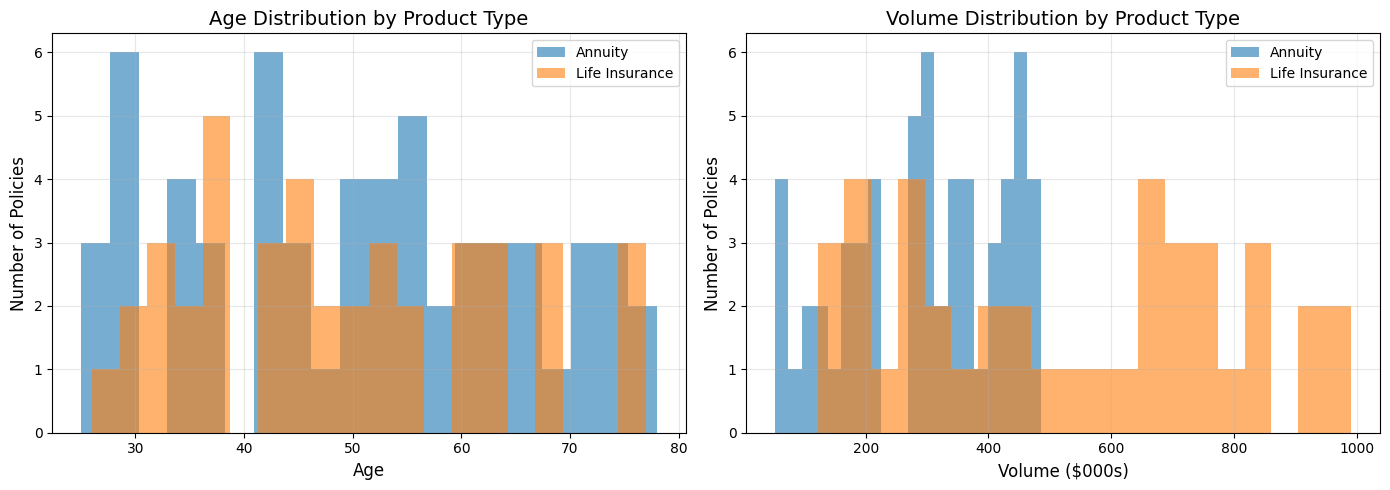

In [5]:
# Visualize portfolio distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by product
for product in portfolio['product_type'].unique():
    subset = portfolio[portfolio['product_type'] == product]
    axes[0].hist(subset['age'], bins=20, alpha=0.6, label=product)
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Number of Policies', fontsize=12)
axes[0].set_title('Age Distribution by Product Type', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Volume distribution
for product in portfolio['product_type'].unique():
    subset = portfolio[portfolio['product_type'] == product]
    axes[1].hist(subset['volume']/1000, bins=20, alpha=0.6, label=product)
axes[1].set_xlabel('Volume ($000s)', fontsize=12)
axes[1].set_ylabel('Number of Policies', fontsize=12)
axes[1].set_title('Volume Distribution by Product Type', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 2. Module 1: The Mortality Shocker

### 2.1 Exposure-Response Function (ERF)

The ERF defines how temperature affects mortality. We use a linear model:

$$RR(\Delta T) = 1 + \beta \cdot \Delta T$$

Where:
- $RR$ = Relative Risk (multiplier on baseline mortality)
- $\Delta T$ = Temperature change in °C
- $\beta$ = Risk coefficient per degree (e.g., 0.02 = 2% per °C)

The adjusted mortality is:

$$q_x^{adjusted} = \min(1, q_x^{baseline} \cdot RR)$$

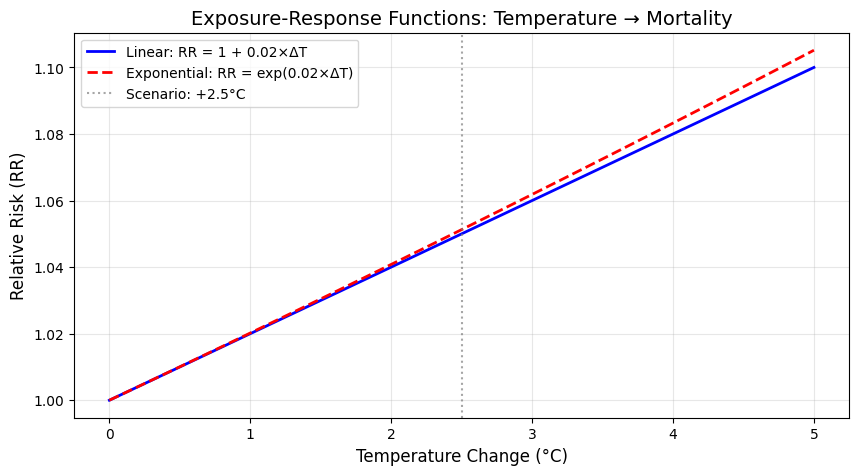

At +2.5°C:
  Linear RR: 1.0500 (5.0% increase)
  Exponential RR: 1.0513 (5.1% increase)


In [4]:
# Define ERF parameters
TEMPERATURE_DELTA = 2.5  # °C increase
RISK_PER_DEGREE = 0.02   # 2% mortality increase per degree

# Create ERF function
erf_linear = create_erf_function(base_risk=1.0, risk_per_degree=RISK_PER_DEGREE, nonlinear=False)
erf_exponential = create_erf_function(base_risk=1.0, risk_per_degree=RISK_PER_DEGREE, nonlinear=True)

# Compare ERF models
temps = np.linspace(0, 5, 50)
rr_linear = [erf_linear(t) for t in temps]
rr_exponential = [erf_exponential(t) for t in temps]

plt.figure(figsize=(10, 5))
plt.plot(temps, rr_linear, 'b-', linewidth=2, label='Linear: RR = 1 + 0.02×ΔT')
plt.plot(temps, rr_exponential, 'r--', linewidth=2, label='Exponential: RR = exp(0.02×ΔT)')
plt.axvline(x=TEMPERATURE_DELTA, color='gray', linestyle=':', alpha=0.7, label=f'Scenario: +{TEMPERATURE_DELTA}°C')
plt.xlabel('Temperature Change (°C)', fontsize=12)
plt.ylabel('Relative Risk (RR)', fontsize=12)
plt.title('Exposure-Response Functions: Temperature → Mortality', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"At +{TEMPERATURE_DELTA}°C:")
print(f"  Linear RR: {erf_linear(TEMPERATURE_DELTA):.4f} ({(erf_linear(TEMPERATURE_DELTA)-1)*100:.1f}% increase)")
print(f"  Exponential RR: {erf_exponential(TEMPERATURE_DELTA):.4f} ({(erf_exponential(TEMPERATURE_DELTA)-1)*100:.1f}% increase)")

### 2.2 Apply the MortalityAdjuster

In [5]:
# Create MortalityAdjuster with +2.5°C scenario
adjuster = MortalityAdjuster(
    baseline_table=mortality_table,
    temperature_delta=TEMPERATURE_DELTA,
    erf_function=erf_linear
)

# Get summary statistics
summary = adjuster.get_summary_statistics()

print("=" * 50)
print(f"MORTALITY ADJUSTMENT SUMMARY (+{TEMPERATURE_DELTA}°C)")
print("=" * 50)
print(f"Relative Risk (RR): {summary['relative_risk']:.4f}")
print(f"Baseline Life Expectancy at Birth: {summary['baseline_life_expectancy_at_birth']:.2f} years")
print(f"Adjusted Life Expectancy at Birth: {summary['adjusted_life_expectancy_at_birth']:.2f} years")
print(f"Life Expectancy Change: {summary['life_expectancy_change']:.2f} years")
print(f"Average Mortality Increase: {summary['avg_mortality_increase_pct']:.2f}%")

MORTALITY ADJUSTMENT SUMMARY (+2.5°C)
Relative Risk (RR): 1.0500
Baseline Life Expectancy at Birth: 78.27 years
Adjusted Life Expectancy at Birth: 77.72 years
Life Expectancy Change: -0.55 years
Average Mortality Increase: 3.95%


In [6]:
# Get comparison table
comparison = adjuster.get_comparison_table()

print("Life Table Comparison (selected ages):")
comparison.loc[comparison['age'].isin([0, 20, 40, 60, 80, 100])]

Life Table Comparison (selected ages):


,age,baseline_qx,adjusted_qx,baseline_lx,adjusted_lx,baseline_ex,adjusted_ex,delta_qx,delta_qx_pct,delta_lx,delta_ex
0,0,0.0060,0.0063,100000.0000,100000.0000,78.2722,77.7243,0.0003,5.0000,0.0000,-0.5479
20,20,0.0003,0.0003,99043.9671,98996.3099,58.9836,58.4660,0.0000,5.0000,-47.6572,-0.5176
40,40,0.0015,0.0015,97710.0419,97596.8074,39.6178,39.1247,0.0001,5.0000,-113.2345,-0.4931
60,60,0.0092,0.0097,90218.7811,89754.5834,21.8448,21.4255,0.0005,5.0000,-464.1977,-0.4193
80,80,0.0597,0.0627,53360.0346,51685.3053,8.5124,8.2546,0.0030,5.0000,-1674.7293,-0.2577
100,100,1.0000,1.0000,1576.8015,1251.4056,0.5000,0.5000,0.0000,0.0000,-325.3959,0.0000


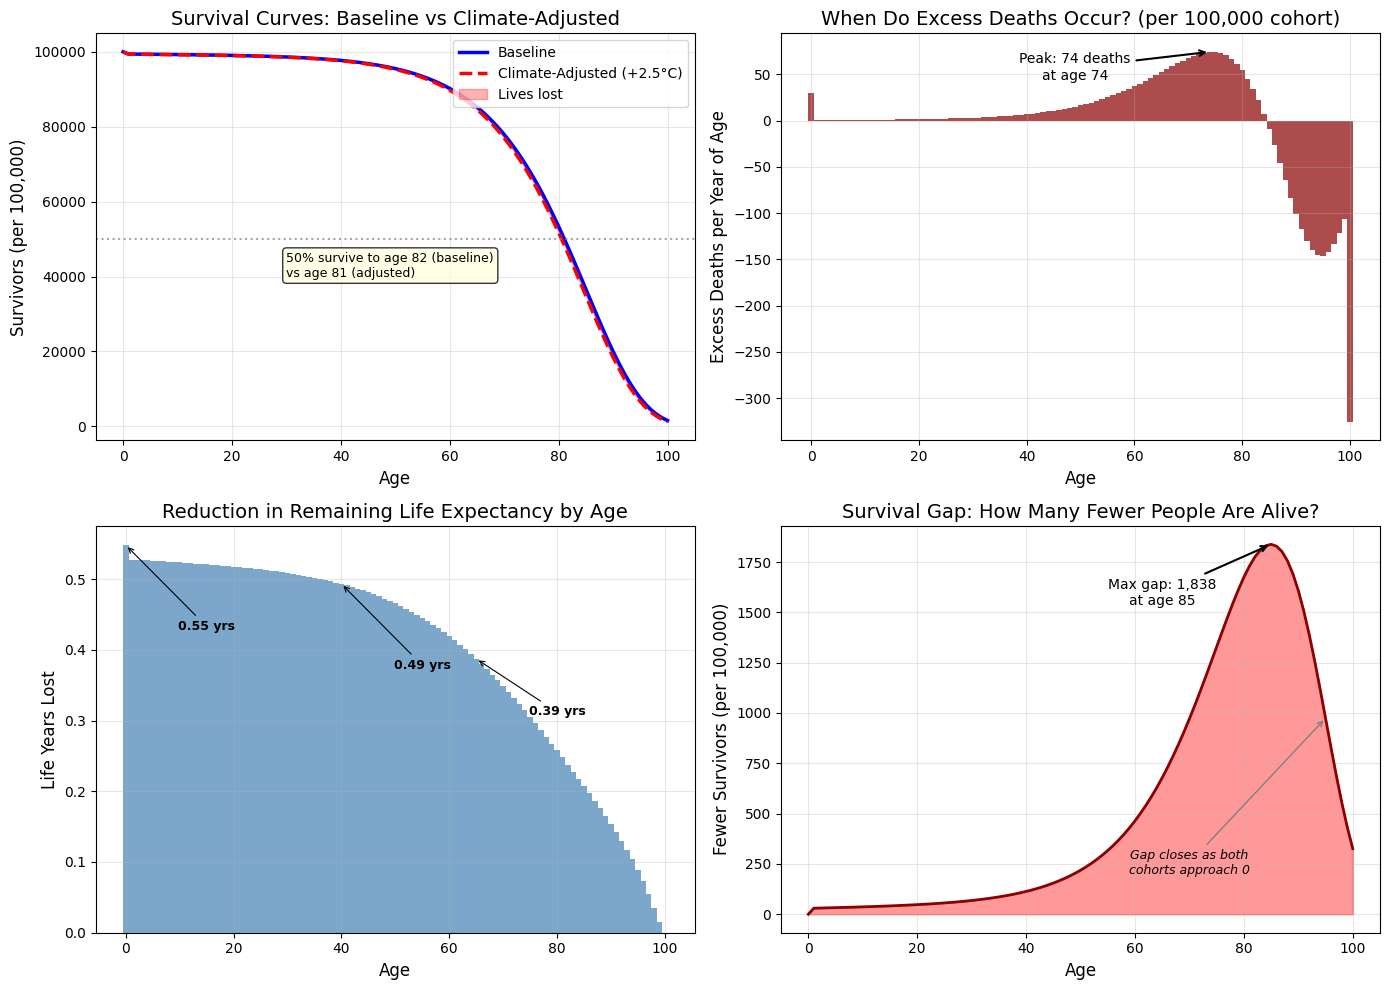


📊 KEY VISUAL INSIGHTS:
   • Median survival: age 82 (baseline) vs age 81 (adjusted)
   • Peak annual excess deaths occur at age 74 (74 deaths)
   • Maximum survival gap of 1,838 occurs at age 85
   • Life expectancy at birth reduced by 0.55 years


In [10]:
# Visualize mortality comparison - Focus on DIFFERENCES and IMPACTS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Calculate excess deaths at each age for later use
baseline_lt = adjuster.baseline_life_table
adjusted_lt = adjuster.adjusted_life_table
excess_deaths_per_age = adjusted_lt['dx'].values - baseline_lt['dx'].values

# 1. Survival Curves Comparison (lx) - Shows the big picture
axes[0, 0].plot(comparison['age'], comparison['baseline_lx'], 'b-', linewidth=2.5, label='Baseline')
axes[0, 0].plot(comparison['age'], comparison['adjusted_lx'], 'r--', linewidth=2.5, label=f'Climate-Adjusted (+{TEMPERATURE_DELTA}°C)')
axes[0, 0].fill_between(comparison['age'], comparison['adjusted_lx'], comparison['baseline_lx'], 
                        color='red', alpha=0.3, label='Lives lost')
axes[0, 0].set_xlabel('Age', fontsize=12)
axes[0, 0].set_ylabel('Survivors (per 100,000)', fontsize=12)
axes[0, 0].set_title('Survival Curves: Baseline vs Climate-Adjusted', fontsize=14)
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# Annotate median survival ages
baseline_median_age = comparison.loc[comparison['baseline_lx'] <= 50000, 'age'].iloc[0]
adjusted_median_age = comparison.loc[comparison['adjusted_lx'] <= 50000, 'age'].iloc[0]
axes[0, 0].axhline(y=50000, color='gray', linestyle=':', alpha=0.7)
axes[0, 0].annotate(f'50% survive to age {baseline_median_age} (baseline)\nvs age {adjusted_median_age} (adjusted)', 
                    xy=(baseline_median_age, 50000), 
                    xytext=(30, 40000),
                    fontsize=9, ha='left',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 2. Annual Excess Deaths by Age (where does the mortality hit hardest?)
axes[0, 1].bar(comparison['age'], excess_deaths_per_age, color='darkred', alpha=0.7, width=1.0)
axes[0, 1].set_xlabel('Age', fontsize=12)
axes[0, 1].set_ylabel('Excess Deaths per Year of Age', fontsize=12)
axes[0, 1].set_title(f'When Do Excess Deaths Occur? (per 100,000 cohort)', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# Find and annotate peak - position below the peak to avoid title
peak_age = comparison['age'].iloc[np.argmax(excess_deaths_per_age)]
peak_deaths = np.max(excess_deaths_per_age)
axes[0, 1].annotate(f'Peak: {peak_deaths:.0f} deaths\nat age {peak_age}', 
                    xy=(peak_age, peak_deaths), 
                    xytext=(peak_age - 25, peak_deaths - 30),
                    fontsize=10, ha='center',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# 3. Life Years Lost by Age (reduction in remaining life expectancy)
life_years_lost = comparison['baseline_ex'] - comparison['adjusted_ex']
axes[1, 0].bar(comparison['age'], life_years_lost, color='steelblue', alpha=0.7, width=1.0)
axes[1, 0].set_xlabel('Age', fontsize=12)
axes[1, 0].set_ylabel('Life Years Lost', fontsize=12)
axes[1, 0].set_title(f'Reduction in Remaining Life Expectancy by Age', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# Highlight key ages - position annotations clearly
axes[1, 0].annotate(f'{life_years_lost.iloc[0]:.2f} yrs', 
                    xy=(0, life_years_lost.iloc[0]), 
                    xytext=(15, life_years_lost.iloc[0] - 0.12),
                    fontsize=9, ha='center', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.8))
axes[1, 0].annotate(f'{life_years_lost.iloc[40]:.2f} yrs', 
                    xy=(40, life_years_lost.iloc[40]), 
                    xytext=(55, life_years_lost.iloc[40] - 0.12),
                    fontsize=9, ha='center', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.8))
axes[1, 0].annotate(f'{life_years_lost.iloc[65]:.2f} yrs', 
                    xy=(65, life_years_lost.iloc[65]), 
                    xytext=(80, life_years_lost.iloc[65] - 0.08),
                    fontsize=9, ha='center', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

# 4. Survival Curve Comparison (zoomed to show difference)
# Show the survival "gap" with better framing
survival_gap = comparison['baseline_lx'] - comparison['adjusted_lx']
axes[1, 1].fill_between(comparison['age'], 0, survival_gap, color='red', alpha=0.4, label='Survival gap (lives lost)')
axes[1, 1].plot(comparison['age'], survival_gap, 'darkred', linewidth=2)
axes[1, 1].set_xlabel('Age', fontsize=12)
axes[1, 1].set_ylabel('Fewer Survivors (per 100,000)', fontsize=12)
axes[1, 1].set_title('Survival Gap: How Many Fewer People Are Alive?', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

# Annotate the peak gap - position to the left of peak
peak_gap_age = comparison['age'].iloc[np.argmax(survival_gap)]
peak_gap = np.max(survival_gap)
axes[1, 1].annotate(f'Max gap: {peak_gap:,.0f}\nat age {peak_gap_age}', 
                    xy=(peak_gap_age, peak_gap), 
                    xytext=(peak_gap_age - 20, peak_gap - 300),
                    fontsize=10, ha='center',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

# Explain why it decreases - bottom right
axes[1, 1].annotate('Gap closes as both\ncohorts approach 0', 
                    xy=(95, survival_gap.iloc[95]), 
                    xytext=(70, 200),
                    fontsize=9, ha='center', style='italic',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1))

plt.tight_layout()
plt.show()

# Print key insights
print(f"\n📊 KEY VISUAL INSIGHTS:")
print(f"   • Median survival: age {baseline_median_age} (baseline) vs age {adjusted_median_age} (adjusted)")
print(f"   • Peak annual excess deaths occur at age {peak_age} ({peak_deaths:.0f} deaths)")
print(f"   • Maximum survival gap of {peak_gap:,.0f} occurs at age {peak_gap_age}")
print(f"   • Life expectancy at birth reduced by {life_years_lost.iloc[0]:.2f} years")

---

## 3. Module 2: The Reserve Calculator

### 3.1 Commutation Functions

Commutation functions simplify actuarial calculations:

$$D_x = v^x \cdot l_x \quad \text{(discounted survivors)}$$

$$N_x = \sum_{t=x}^{\omega} D_t \quad \text{(sum of Dx)}$$

$$C_x = v^{x+1} \cdot d_x \quad \text{(discounted deaths)}$$

$$M_x = \sum_{t=x}^{\omega} C_t \quad \text{(sum of Cx)}$$

Where $v = \frac{1}{1+i}$ is the discount factor.

In [10]:
# Set interest rate
INTEREST_RATE = 0.01  # 1%

# Create valuation objects for both scenarios
baseline_life_table = adjuster.baseline_life_table
adjusted_life_table = adjuster.adjusted_life_table

valuation_baseline = PortfolioValuation(
    life_table=baseline_life_table,
    interest_rate=INTEREST_RATE,
    portfolio_data=portfolio
)

valuation_adjusted = PortfolioValuation(
    life_table=adjusted_life_table,
    interest_rate=INTEREST_RATE,
    portfolio_data=portfolio
)

print(f"Interest rate: {INTEREST_RATE*100:.1f}%")
print(f"Discount factor (v): {valuation_baseline.discount_factor:.6f}")

Interest rate: 1.0%
Discount factor (v): 0.990099


In [11]:
# View commutation functions
comm_baseline = valuation_baseline.commutation_functions
print("Baseline Commutation Functions (selected ages):")
comm_baseline.loc[comm_baseline['age'].isin([0, 20, 40, 60, 80, 100])]

Baseline Commutation Functions (selected ages):


,age,Dx,Nx,Cx,Mx
0,0,100000.0000,5430538.8872,594.0594,46232.2882
20,20,81170.9356,3620676.6321,24.2532,45322.6521
40,40,65627.2564,2147898.4451,94.6537,44360.9351
60,60,49660.8934,981135.5800,451.9605,39946.6798
80,80,24071.6688,205334.7104,1422.7538,22038.6519
100,100,582.9612,582.9612,577.1893,577.1893


### 3.2 Actuarial Present Values

Using commutation functions, we calculate:

**Whole Life Annuity Due** ($\ddot{a}_x$): Present value of \$1/year while alive
$$\ddot{a}_x = \frac{N_x}{D_x}$$

**Whole Life Insurance** ($A_x$): Present value of \$1 paid at death
$$A_x = \frac{M_x}{D_x}$$

In [12]:
# View actuarial values
actuarial_baseline = valuation_baseline.actuarial_values
actuarial_adjusted = valuation_adjusted.actuarial_values

print("Baseline Actuarial Values (selected ages):")
actuarial_baseline.loc[actuarial_baseline['age'].isin([30, 40, 50, 60, 70, 80])][['age', 'annuity_due_ax', 'whole_life_Ax']]

Baseline Actuarial Values (selected ages):


,age,annuity_due_ax,whole_life_Ax
30,30,38.8861,0.6150
40,40,32.7288,0.6760
50,50,26.2615,0.7400
60,60,19.7567,0.8044
70,70,13.6629,0.8647
80,80,8.5301,0.9155


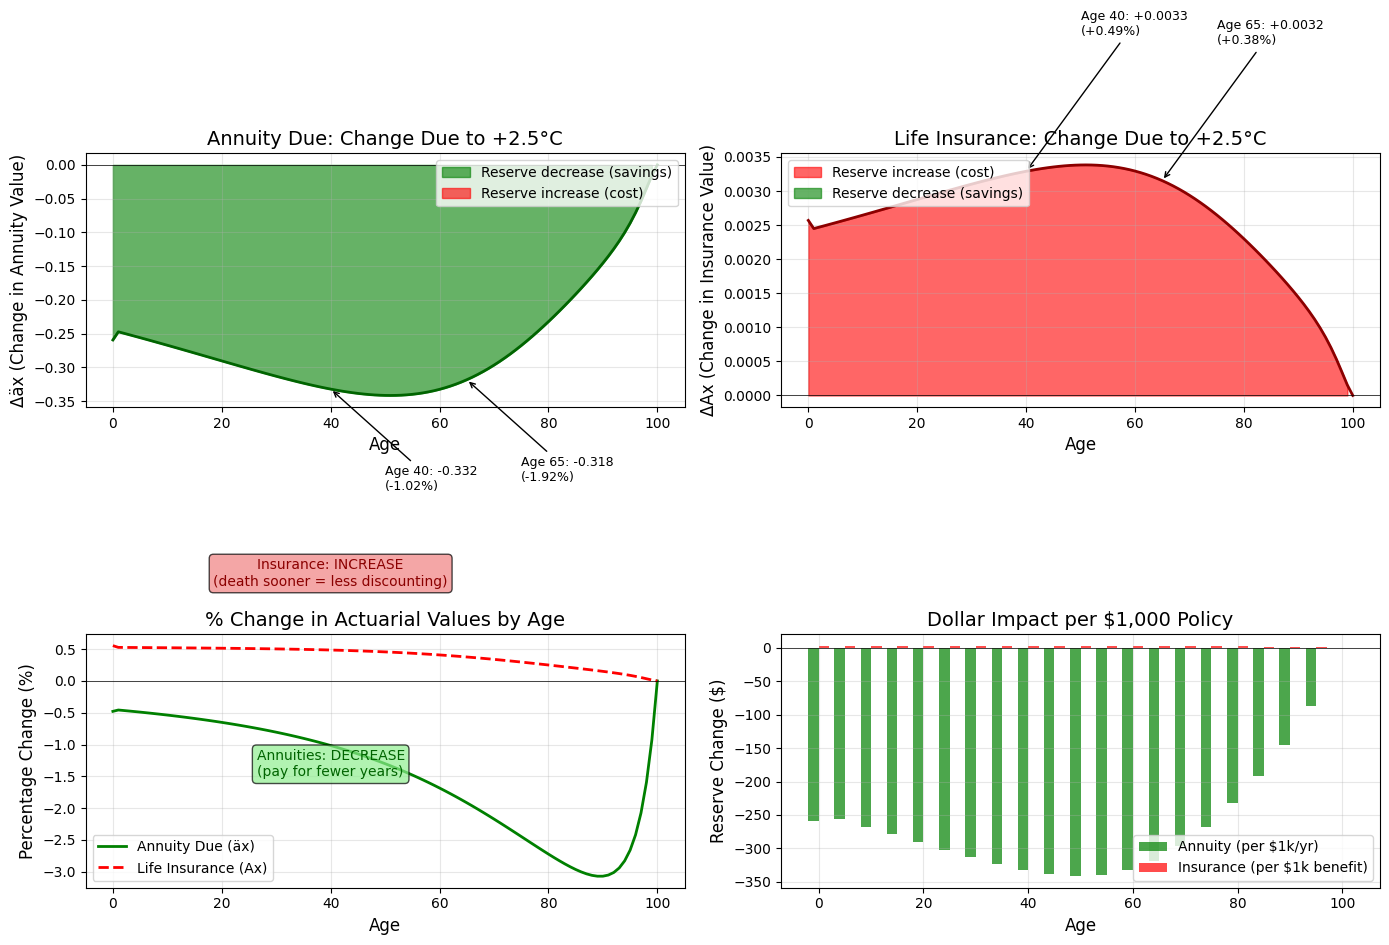


📊 ACTUARIAL VALUE INSIGHTS (+2.5°C):

   ANNUITY DUE (äx) - Present value of $1/year while alive:
      • At age 40: äx decreases by 0.332 (1.02%)
      • At age 65: äx decreases by 0.318 (1.92%)
      → Insurers SAVE money (fewer years of payments expected)

   LIFE INSURANCE (Ax) - Present value of $1 at death:
      • At age 40: Ax increases by 0.0033 (0.49%)
      • At age 65: Ax increases by 0.0032 (0.38%)
      → Insurers NEED MORE reserves (death benefit paid sooner)


In [22]:
# Visualize actuarial values - Focus on DIFFERENCES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Calculate differences
annuity_diff = actuarial_adjusted['annuity_due_ax'].values - actuarial_baseline['annuity_due_ax'].values
insurance_diff = actuarial_adjusted['whole_life_Ax'].values - actuarial_baseline['whole_life_Ax'].values
annuity_pct_diff = (annuity_diff / actuarial_baseline['annuity_due_ax'].values) * 100
insurance_pct_diff = (insurance_diff / actuarial_baseline['whole_life_Ax'].values) * 100

# 1. Annuity Due - Absolute Difference (should be NEGATIVE - people die sooner)
axes[0, 0].fill_between(actuarial_baseline['age'], 0, annuity_diff, 
                        where=(annuity_diff < 0), color='green', alpha=0.6, label='Reserve decrease (savings)')
axes[0, 0].fill_between(actuarial_baseline['age'], 0, annuity_diff, 
                        where=(annuity_diff >= 0), color='red', alpha=0.6, label='Reserve increase (cost)')
axes[0, 0].plot(actuarial_baseline['age'], annuity_diff, 'darkgreen', linewidth=2)
axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 0].set_xlabel('Age', fontsize=12)
axes[0, 0].set_ylabel('Δäx (Change in Annuity Value)', fontsize=12)
axes[0, 0].set_title(f'Annuity Due: Change Due to +{TEMPERATURE_DELTA}°C', fontsize=14)
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# Annotate key ages
for age in [40, 65]:
    idx = actuarial_baseline[actuarial_baseline['age'] == age].index[0]
    axes[0, 0].annotate(f'Age {age}: {annuity_diff[idx]:.3f}\n({annuity_pct_diff[idx]:.2f}%)', 
                        xy=(age, annuity_diff[idx]), 
                        xytext=(age+10, annuity_diff[idx] - 0.15),
                        fontsize=9, ha='left',
                        arrowprops=dict(arrowstyle='->', color='black', lw=1))

# 2. Whole Life Insurance - Absolute Difference (should be POSITIVE - death comes sooner, less discounting)
axes[0, 1].fill_between(actuarial_baseline['age'], 0, insurance_diff, 
                        where=(insurance_diff > 0), color='red', alpha=0.6, label='Reserve increase (cost)')
axes[0, 1].fill_between(actuarial_baseline['age'], 0, insurance_diff, 
                        where=(insurance_diff <= 0), color='green', alpha=0.6, label='Reserve decrease (savings)')
axes[0, 1].plot(actuarial_baseline['age'], insurance_diff, 'darkred', linewidth=2)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].set_xlabel('Age', fontsize=12)
axes[0, 1].set_ylabel('ΔAx (Change in Insurance Value)', fontsize=12)
axes[0, 1].set_title(f'Life Insurance: Change Due to +{TEMPERATURE_DELTA}°C', fontsize=14)
axes[0, 1].legend(loc='upper left')
axes[0, 1].grid(True, alpha=0.3)

# Annotate key ages
for age in [40, 65]:
    idx = actuarial_baseline[actuarial_baseline['age'] == age].index[0]
    axes[0, 1].annotate(f'Age {age}: +{insurance_diff[idx]:.4f}\n(+{insurance_pct_diff[idx]:.2f}%)', 
                        xy=(age, insurance_diff[idx]), 
                        xytext=(age+10, insurance_diff[idx] + 0.002),
                        fontsize=9, ha='left',
                        arrowprops=dict(arrowstyle='->', color='black', lw=1))

# 3. Percentage Change by Age - Both Products
axes[1, 0].plot(actuarial_baseline['age'], annuity_pct_diff, 'g-', linewidth=2, label='Annuity Due (äx)')
axes[1, 0].plot(actuarial_baseline['age'], insurance_pct_diff, 'r--', linewidth=2, label='Life Insurance (Ax)')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].set_xlabel('Age', fontsize=12)
axes[1, 0].set_ylabel('Percentage Change (%)', fontsize=12)
axes[1, 0].set_title(f'% Change in Actuarial Values by Age', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Add interpretive annotation
axes[1, 0].annotate('Annuities: DECREASE\n(pay for fewer years)', 
                    xy=(30, annuity_pct_diff[30]), xytext=(40, -1.5),
                    fontsize=10, ha='center', color='darkgreen',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
axes[1, 0].annotate('Insurance: INCREASE\n(death sooner = less discounting)', 
                    xy=(30, insurance_pct_diff[30]), xytext=(40, 1.5),
                    fontsize=10, ha='center', color='darkred',
                    bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

# 4. Dollar Impact per $1000 Policy by Age
dollar_annuity_impact = annuity_diff * 1000  # Per $1000 annual annuity
dollar_insurance_impact = insurance_diff * 1000  # Per $1000 death benefit

axes[1, 1].bar(actuarial_baseline['age'][::5] - 1, dollar_annuity_impact[::5], 
               width=2, color='green', alpha=0.7, label='Annuity (per $1k/yr)')
axes[1, 1].bar(actuarial_baseline['age'][::5] + 1, dollar_insurance_impact[::5], 
               width=2, color='red', alpha=0.7, label='Insurance (per $1k benefit)')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].set_xlabel('Age', fontsize=12)
axes[1, 1].set_ylabel('Reserve Change ($)', fontsize=12)
axes[1, 1].set_title(f'Dollar Impact per $1,000 Policy', fontsize=14)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key insights
print(f"\n📊 ACTUARIAL VALUE INSIGHTS (+{TEMPERATURE_DELTA}°C):")
print(f"\n   ANNUITY DUE (äx) - Present value of $1/year while alive:")
print(f"      • At age 40: äx decreases by {abs(annuity_diff[40]):.3f} ({abs(annuity_pct_diff[40]):.2f}%)")
print(f"      • At age 65: äx decreases by {abs(annuity_diff[65]):.3f} ({abs(annuity_pct_diff[65]):.2f}%)")
print(f"      → Insurers SAVE money (fewer years of payments expected)")
print(f"\n   LIFE INSURANCE (Ax) - Present value of $1 at death:")
print(f"      • At age 40: Ax increases by {insurance_diff[40]:.4f} ({insurance_pct_diff[40]:.2f}%)")
print(f"      • At age 65: Ax increases by {insurance_diff[65]:.4f} ({insurance_pct_diff[65]:.2f}%)")
print(f"      → Insurers NEED MORE reserves (death benefit paid sooner)")

### 3.3 Portfolio Reserve Calculation

In [14]:
# Calculate reserves for each policy
reserves_baseline = valuation_baseline.calculate_policy_reserves()
reserves_adjusted = valuation_adjusted.calculate_policy_reserves()

print("Sample Policy Reserves:")
reserves_baseline.head(10)[['age', 'product_type', 'volume', 'reserve']]

Sample Policy Reserves:


,age,product_type,volume,reserve
0,46,Annuity,338914.2408,9785133.1545
1,75,Life Insurance,175725.9685,156685.3421
2,61,Annuity,122732.9213,2346656.0763
3,55,Annuity,454349.3848,10445388.7601
4,35,Life Insurance,645786.1537,416519.8884
5,35,Annuity,54138.6732,1941245.2657
6,29,Annuity,95662.1943,3776644.6593
7,69,Life Insurance,697151.5922,598873.7335
8,55,Annuity,52277.7127,1201852.6957
9,60,Annuity,122363.6231,2417501.9033


In [15]:
# Get portfolio summaries
summary_baseline = valuation_baseline.get_portfolio_summary()
summary_adjusted = valuation_adjusted.get_portfolio_summary()

print("=" * 60)
print("PORTFOLIO RESERVE SUMMARY")
print("=" * 60)
print(f"\nBASELINE SCENARIO:")
print(f"  Annuity Reserves:       ${summary_baseline['annuity_reserves']:>15,.0f}")
print(f"  Life Insurance Reserves:${summary_baseline['life_insurance_reserves']:>15,.0f}")
print(f"  Total Reserves:         ${summary_baseline['total_reserves']:>15,.0f}")

print(f"\nADJUSTED SCENARIO (+{TEMPERATURE_DELTA}°C):")
print(f"  Annuity Reserves:       ${summary_adjusted['annuity_reserves']:>15,.0f}")
print(f"  Life Insurance Reserves:${summary_adjusted['life_insurance_reserves']:>15,.0f}")
print(f"  Total Reserves:         ${summary_adjusted['total_reserves']:>15,.0f}")

PORTFOLIO RESERVE SUMMARY

BASELINE SCENARIO:
  Annuity Reserves:       $    459,133,735
  Life Insurance Reserves:$     15,651,043
  Total Reserves:         $    474,784,778

ADJUSTED SCENARIO (+2.5°C):
  Annuity Reserves:       $    453,495,030
  Life Insurance Reserves:$     15,720,206
  Total Reserves:         $    469,215,236


---

## 4. Full Climate Impact Analysis

Using the `ClimateRiskEngine` to combine both modules and generate a comprehensive impact report.

In [16]:
# Run full climate risk analysis
engine = ClimateRiskEngine(
    baseline_mortality=mortality_table,
    portfolio=portfolio,
    interest_rate=INTEREST_RATE,
    temperature_delta=TEMPERATURE_DELTA,
    erf_function=erf_linear
)

# Generate comprehensive report
report = engine.generate_impact_report()

print("=" * 70)
print(f"CLIMATE RISK IMPACT REPORT (+{TEMPERATURE_DELTA}°C SCENARIO)")
print("=" * 70)

print("\n📊 SCENARIO PARAMETERS:")
print(f"   Temperature Change: +{report['scenario']['temperature_delta_celsius']}°C")
print(f"   Relative Risk (RR): {report['scenario']['relative_risk']:.4f}")
print(f"   Interest Rate: {report['scenario']['interest_rate']*100:.1f}%")

print("\n💀 MORTALITY IMPACT:")
print(f"   Baseline Life Expectancy: {report['mortality_impact']['baseline_life_expectancy']:.2f} years")
print(f"   Adjusted Life Expectancy: {report['mortality_impact']['adjusted_life_expectancy']:.2f} years")
print(f"   Change in Life Expectancy: {report['mortality_impact']['life_expectancy_change_years']:.2f} years")
print(f"   Average Mortality Increase: {report['mortality_impact']['average_mortality_increase_pct']:.2f}%")

print("\n💰 RESERVE IMPACT:")
print(f"   BASELINE RESERVES:")
print(f"      Annuities:       ${report['baseline_reserves']['annuities']:>15,.0f}")
print(f"      Life Insurance:  ${report['baseline_reserves']['life_insurance']:>15,.0f}")
print(f"      Total:           ${report['baseline_reserves']['total']:>15,.0f}")

print(f"\n   ADJUSTED RESERVES:")
print(f"      Annuities:       ${report['adjusted_reserves']['annuities']:>15,.0f}")
print(f"      Life Insurance:  ${report['adjusted_reserves']['life_insurance']:>15,.0f}")
print(f"      Total:           ${report['adjusted_reserves']['total']:>15,.0f}")

print("\n⚡ CLIMATE IMPACT (DELTA):")
print(f"      Annuities:       ${report['climate_impact_delta']['annuities']:>15,.0f}")
print(f"      Life Insurance:  ${report['climate_impact_delta']['life_insurance']:>15,.0f}")
print(f"      Total:           ${report['climate_impact_delta']['total']:>15,.0f}")
print(f"      % Change:        {report['climate_impact_delta']['total_pct_change']:>15.2f}%")

print("\n📋 INTERPRETATION:")
print(f"   {report['climate_impact_delta']['annuities_interpretation']}")
print(f"   {report['climate_impact_delta']['life_insurance_interpretation']}")

CLIMATE RISK IMPACT REPORT (+2.5°C SCENARIO)

📊 SCENARIO PARAMETERS:
   Temperature Change: +2.5°C
   Relative Risk (RR): 1.0500
   Interest Rate: 1.0%

💀 MORTALITY IMPACT:
   Baseline Life Expectancy: 78.27 years
   Adjusted Life Expectancy: 77.72 years
   Change in Life Expectancy: -0.55 years
   Average Mortality Increase: 3.95%

💰 RESERVE IMPACT:
   BASELINE RESERVES:
      Annuities:       $    459,133,735
      Life Insurance:  $     15,651,043
      Total:           $    474,784,778

   ADJUSTED RESERVES:
      Annuities:       $    453,495,030
      Life Insurance:  $     15,720,206
      Total:           $    469,215,236

⚡ CLIMATE IMPACT (DELTA):
      Annuities:       $     -5,638,706
      Life Insurance:  $         69,163
      Total:           $     -5,569,542
      % Change:                  -1.17%

📋 INTERPRETATION:
   Negative = lower reserves needed (shorter life expectancy)
   Positive = higher reserves needed


## 5. Multi-Scenario Stress Testing

In [17]:
# Run analysis for multiple temperature scenarios
temperature_scenarios = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

results = []
for temp in temperature_scenarios:
    engine = ClimateRiskEngine(
        baseline_mortality=mortality_table,
        portfolio=portfolio,
        interest_rate=INTEREST_RATE,
        temperature_delta=temp,
        erf_function=erf_linear
    )
    report = engine.generate_impact_report()
    results.append({
        'temp_delta': temp,
        'relative_risk': report['scenario']['relative_risk'],
        'life_exp_change': report['mortality_impact']['life_expectancy_change_years'],
        'baseline_reserves': report['baseline_reserves']['total'],
        'adjusted_reserves': report['adjusted_reserves']['total'],
        'delta_total': report['climate_impact_delta']['total'],
        'delta_pct': report['climate_impact_delta']['total_pct_change'],
        'delta_annuity': report['climate_impact_delta']['annuities'],
        'delta_insurance': report['climate_impact_delta']['life_insurance']
    })

results_df = pd.DataFrame(results)
results_df

,temp_delta,relative_risk,life_exp_change,baseline_reserves,adjusted_reserves,delta_total,delta_pct,delta_annuity,delta_insurance
0,1.0000,1.0200,-0.2221,474784778.3110,472525046.5876,-2259731.7234,-0.4759,-2287787.8039,28056.0805
1,1.5000,1.0300,-0.3317,474784778.3110,471411312.9315,-3373465.3795,-0.7105,-3415351.9839,41886.6044
2,2.0000,1.0400,-0.4403,474784778.3110,470308099.7697,-4476678.5413,-0.9429,-4532266.8534,55588.3120
3,2.5000,1.0500,-0.5479,474784778.3110,469215235.9973,-5569542.3137,-1.1731,-5638705.6065,69163.2927
4,3.0000,1.0600,-0.6546,474784778.3110,468132554.1054,-6652224.2056,-1.4011,-6734837.7974,82613.5918
5,3.5000,1.0700,-0.7604,474784778.3110,467059890.0958,-7724888.2152,-1.6270,-7820829.4269,95941.2117
6,4.0000,1.0800,-0.8652,474784778.3110,465997083.3974,-8787694.9137,-1.8509,-8896843.0264,109148.1127


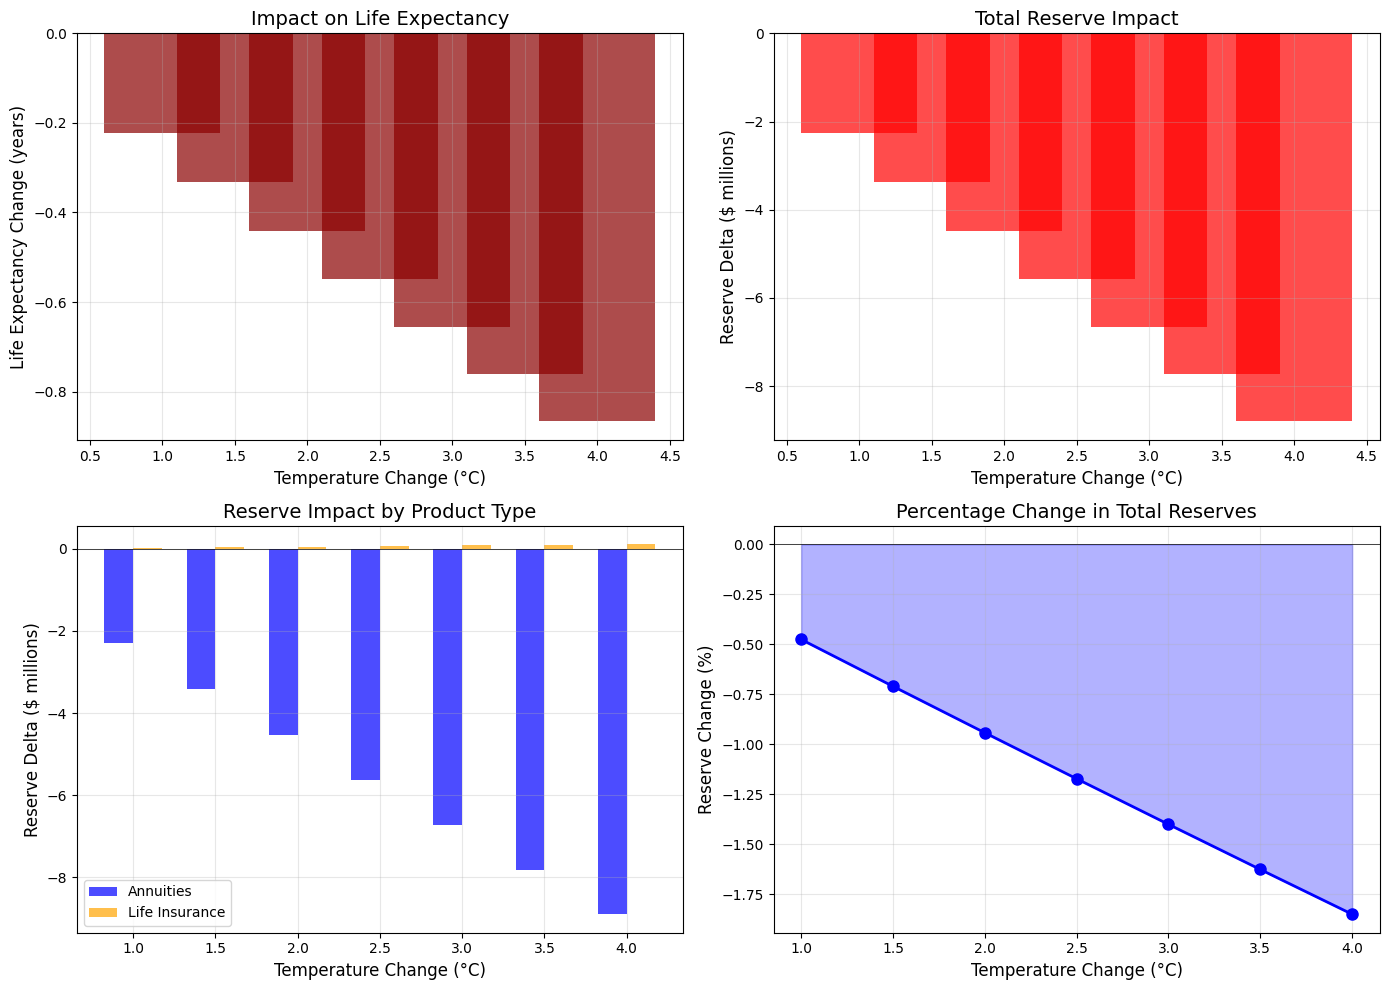

In [18]:
# Visualize multi-scenario results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Life expectancy change
axes[0, 0].bar(results_df['temp_delta'], results_df['life_exp_change'], color='darkred', alpha=0.7)
axes[0, 0].set_xlabel('Temperature Change (°C)', fontsize=12)
axes[0, 0].set_ylabel('Life Expectancy Change (years)', fontsize=12)
axes[0, 0].set_title('Impact on Life Expectancy', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)

# Total reserve delta
colors = ['green' if x >= 0 else 'red' for x in results_df['delta_total']]
axes[0, 1].bar(results_df['temp_delta'], results_df['delta_total']/1e6, color=colors, alpha=0.7)
axes[0, 1].set_xlabel('Temperature Change (°C)', fontsize=12)
axes[0, 1].set_ylabel('Reserve Delta ($ millions)', fontsize=12)
axes[0, 1].set_title('Total Reserve Impact', fontsize=14)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].grid(True, alpha=0.3)

# Delta by product type
x = np.arange(len(results_df))
width = 0.35
axes[1, 0].bar(x - width/2, results_df['delta_annuity']/1e6, width, label='Annuities', color='blue', alpha=0.7)
axes[1, 0].bar(x + width/2, results_df['delta_insurance']/1e6, width, label='Life Insurance', color='orange', alpha=0.7)
axes[1, 0].set_xlabel('Temperature Change (°C)', fontsize=12)
axes[1, 0].set_ylabel('Reserve Delta ($ millions)', fontsize=12)
axes[1, 0].set_title('Reserve Impact by Product Type', fontsize=14)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(results_df['temp_delta'])
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Percentage change
axes[1, 1].plot(results_df['temp_delta'], results_df['delta_pct'], 'b-o', linewidth=2, markersize=8)
axes[1, 1].fill_between(results_df['temp_delta'], results_df['delta_pct'], 0, alpha=0.3, color='blue')
axes[1, 1].set_xlabel('Temperature Change (°C)', fontsize=12)
axes[1, 1].set_ylabel('Reserve Change (%)', fontsize=12)
axes[1, 1].set_title('Percentage Change in Total Reserves', fontsize=14)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary & Key Insights

### Key Findings:

1. **Mortality Impact**: Each degree of warming increases mortality by ~2%, reducing life expectancy by approximately 0.2-0.3 years per degree.

2. **Annuity Reserves (Decrease)**: Higher mortality → shorter expected lifetimes → insurers pay out for fewer years → **lower reserves needed**

3. **Life Insurance Reserves (Increase)**: Higher mortality → deaths occur sooner → less time for discounting → **higher present value of death benefits**

4. **Net Portfolio Effect**: For this mixed portfolio (60% annuities, 40% life insurance), the annuity effect dominates, resulting in a net **decrease** in required reserves.

### Actuarial Implications:

- **Risk Management**: Climate change creates offsetting effects between annuities and life insurance
- **Capital Planning**: The net effect depends heavily on portfolio composition
- **Product Pricing**: Products should incorporate climate risk scenarios in pricing models

In [19]:
print("🎯 EXECUTIVE SUMMARY")
print("=" * 70)
print(f"\nFor a +2.5°C warming scenario with {len(portfolio)} policies:")
print(f"\n  📉 Life expectancy decreases by {abs(results_df[results_df['temp_delta']==2.5]['life_exp_change'].values[0]):.2f} years")
print(f"  📉 Annuity reserves decrease by ${abs(results_df[results_df['temp_delta']==2.5]['delta_annuity'].values[0]):,.0f}")
print(f"  📈 Life insurance reserves increase by ${abs(results_df[results_df['temp_delta']==2.5]['delta_insurance'].values[0]):,.0f}")
print(f"  📊 Net portfolio impact: ${results_df[results_df['temp_delta']==2.5]['delta_total'].values[0]:,.0f}")
print(f"     ({results_df[results_df['temp_delta']==2.5]['delta_pct'].values[0]:.2f}% change in total reserves)")
print("\n" + "=" * 70)

🎯 EXECUTIVE SUMMARY

For a +2.5°C warming scenario with 100 policies:

  📉 Life expectancy decreases by 0.55 years
  📉 Annuity reserves decrease by $5,638,706
  📈 Life insurance reserves increase by $69,163
  📊 Net portfolio impact: $-5,569,542
     (-1.17% change in total reserves)

